## Nội dung

- Feature engineering
- Phân cụm: KMeans, DBSCAN
- Kết hợp phân cụm và phân tích mô tả
- Kết hợp PCA và phân cụm
- Tập dữ liệu:
   1. Customer Personality Analysis (nguồn: https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis)
   2. Taxi geolocation (nguồn: https://www.coursera.org/projects/clustering-geolocation-data-intelligently-python)

#### Cài đặt thư viện

In [25]:
!pip install folium
!pip install kneed
!pip install yellowbrick
!pip install kneed

'pip' is not recognized as an internal or external command,
operable program or batch file.
'pip' is not recognized as an internal or external command,
operable program or batch file.
'pip' is not recognized as an internal or external command,
operable program or batch file.
'pip' is not recognized as an internal or external command,
operable program or batch file.


### A. Customer Personality Analysis

#### A1. Đọc dữ liệu

In [26]:
import numpy as np
import pandas as pd

In [27]:
pd.set_option('display.max_columns', None)
customer_data = pd.read_csv('data/marketing_campaign.csv',
                           delimiter='\t', index_col='ID')
customer_data.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,
5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


#### A2. Làm sạch
- Làm sạch dữ liệu.
- Trích xuất đặc trưng (đọc thêm: https://machinelearningcoban.com/general/2017/02/06/featureengineering/)

In [28]:
customer_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2240 entries, 5524 to 9405
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Year_Birth           2240 non-null   int64  
 1   Education            2240 non-null   object 
 2   Marital_Status       2240 non-null   object 
 3   Income               2216 non-null   float64
 4   Kidhome              2240 non-null   int64  
 5   Teenhome             2240 non-null   int64  
 6   Dt_Customer          2240 non-null   object 
 7   Recency              2240 non-null   int64  
 8   MntWines             2240 non-null   int64  
 9   MntFruits            2240 non-null   int64  
 10  MntMeatProducts      2240 non-null   int64  
 11  MntFishProducts      2240 non-null   int64  
 12  MntSweetProducts     2240 non-null   int64  
 13  MntGoldProds         2240 non-null   int64  
 14  NumDealsPurchases    2240 non-null   int64  
 15  NumWebPurchases      2240 non-null   int

Dữ liệu khá sạch và chỉ có 1 số lượng nhỏ income bị thiếu dữ liệu, có thể xử lý bằng cách thêm vào mean. Mã hoá 1 số đặc trưng kiểu loại.

In [29]:
# Xử lý dữ liệu khuyết cho Income bằng cách thêm mean
print('Số dòng thiếu Income:', customer_data['Income'].isna().sum())
customer_data['Income'] = customer_data['Income'].fillna(customer_data['Income'].mean())
print('Sau khi xử lý:', customer_data['Income'].isna().sum())

Số dòng thiếu Income: 24
Sau khi xử lý: 0


#### A3. Feature engineering

In [30]:
import datetime

Đầu tiên là dữ liệu liên quan ngày tháng.

- `Year_Birth` không phải là đặc trưng lý tưởng cho bài toán này, ta sẽ chuyển nó sang thành tuổi `Age` (tính từ hiện tại)

In [31]:
# Trích xuất tuổi từ đặc trưng năm sinh
# hint: 2022 - x
customer_data['Age'] = 2022 - customer_data['Year_Birth']

- `Days_Since_Customer`, tương tự như `Year_Birth`, nên được chuyển thành số ngày đã tham gia `Enroll_days`.

In [32]:
# Đặc trưng 'Days_Since_Customer' ~ ngày tham gia, biến đổi thành số lượng ngày đã tham gia
# (ngày trong file có dạng ngày-tháng-năm nên khai báo format cho đúng)
customer_data['Dt_Customer'] = pd.to_datetime(customer_data['Dt_Customer'], format='%d-%m-%Y')
now = datetime.datetime.now()
customer_data['Enroll_days'] = (now - customer_data['Dt_Customer']).dt.days

- Các đặc trưng `Marital_Status`, `Kidhome`, `Teenhome` có thể được gom lại 1 thuộc tính duy nhất --> cô động hơn

In [33]:
# Tạo ra đặc trưng Fam_size (số người trong gia đình)
# bằng cách gộp các đặc trưng: Martial_Status, Kidhome, Teenhome
marital_map = {
    'Absurd': 1, 'Alone': 1,
    'YOLO': 1, 'Single': 1,
    'Married': 2, 'Together': 2,
    'Widow': 1, 'Divorced': 1
} # married/together->2 người, khác-> 1 người
customer_data['Marital_Status'] = customer_data['Marital_Status'].map(marital_map)
customer_data['Fam_Size'] = customer_data['Marital_Status'] + customer_data['Kidhome'] + customer_data['Teenhome']

- Gom các đặc trưng `AcceptedCmpX` thành 1 đặc trưng `Num_Accepted` (tổng)
- Làm tương tự cho các đặc trưng MntX, gom thành đặc trưng `MntTotal`

In [34]:
# Num_Accepted = AcceptedCmp1 + AcceptedCmp2 + ...
customer_data['Num_Accepted'] = (customer_data['AcceptedCmp1'] + customer_data['AcceptedCmp2'] +
                                 customer_data['AcceptedCmp3'] + customer_data['AcceptedCmp4'] +
                                 customer_data['AcceptedCmp5'])

In [35]:
# Có thể gộp các đặc trưng MntXXX thành 1 thuộc tính duy nhất (tính tổng)
mnt_cols = ['MntWines', 'MntFruits', 'MntMeatProducts',
            'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
customer_data['MntTotal'] = customer_data[mnt_cols].sum(axis=1)

#### A4. Phân tích EDA

In [36]:
customer_data.describe()

,Year_Birth,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Enroll_days,Fam_Size,Num_Accepted,MntTotal
count,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,1968.805804,1.644643,52247.251354,0.444196,0.506250,2013-07-10 10:01:42.857142784,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,2.325000,4.084821,2.662054,5.790179,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107,53.194196,4838.582143,2.595089,0.297768,605.798214
min,1893.000000,1.000000,1730.000000,0.000000,0.000000,2012-07-30 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,26.000000,4485.000000,1.000000,0.000000,5.000000
25%,1959.000000,1.000000,35538.750000,0.000000,0.000000,2013-01-16 00:00:00,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,45.000000,4665.750000,2.000000,0.000000,68.750000
50%,1970.000000,2.000000,51741.500000,0.000000,0.000000,2013-07-08 12:00:00,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,52.000000,4840.500000,3.000000,0.000000,396.000000
75%,1977.000000,2.000000,68289.750000,1.000000,1.000000,2013-12-30 06:00:00,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,63.000000,5014.000000,3.000000,0.000000,1045.500000
max,1996.000000,2.000000,666666.000000,2.000000,2.000000,2014-06-29 00:00:00,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,15.000000,27.000000,28.000000,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000,129.000000,5184.000000,5.000000,4.000000,2525.000000
std,11.984069,0.478728,25037.797168,0.538398,0.544538,NaN,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,1.932238,2.778714,2.923101,3.250958,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274,11.984069,202.122512,0.906959,0.678381,602.249288


In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

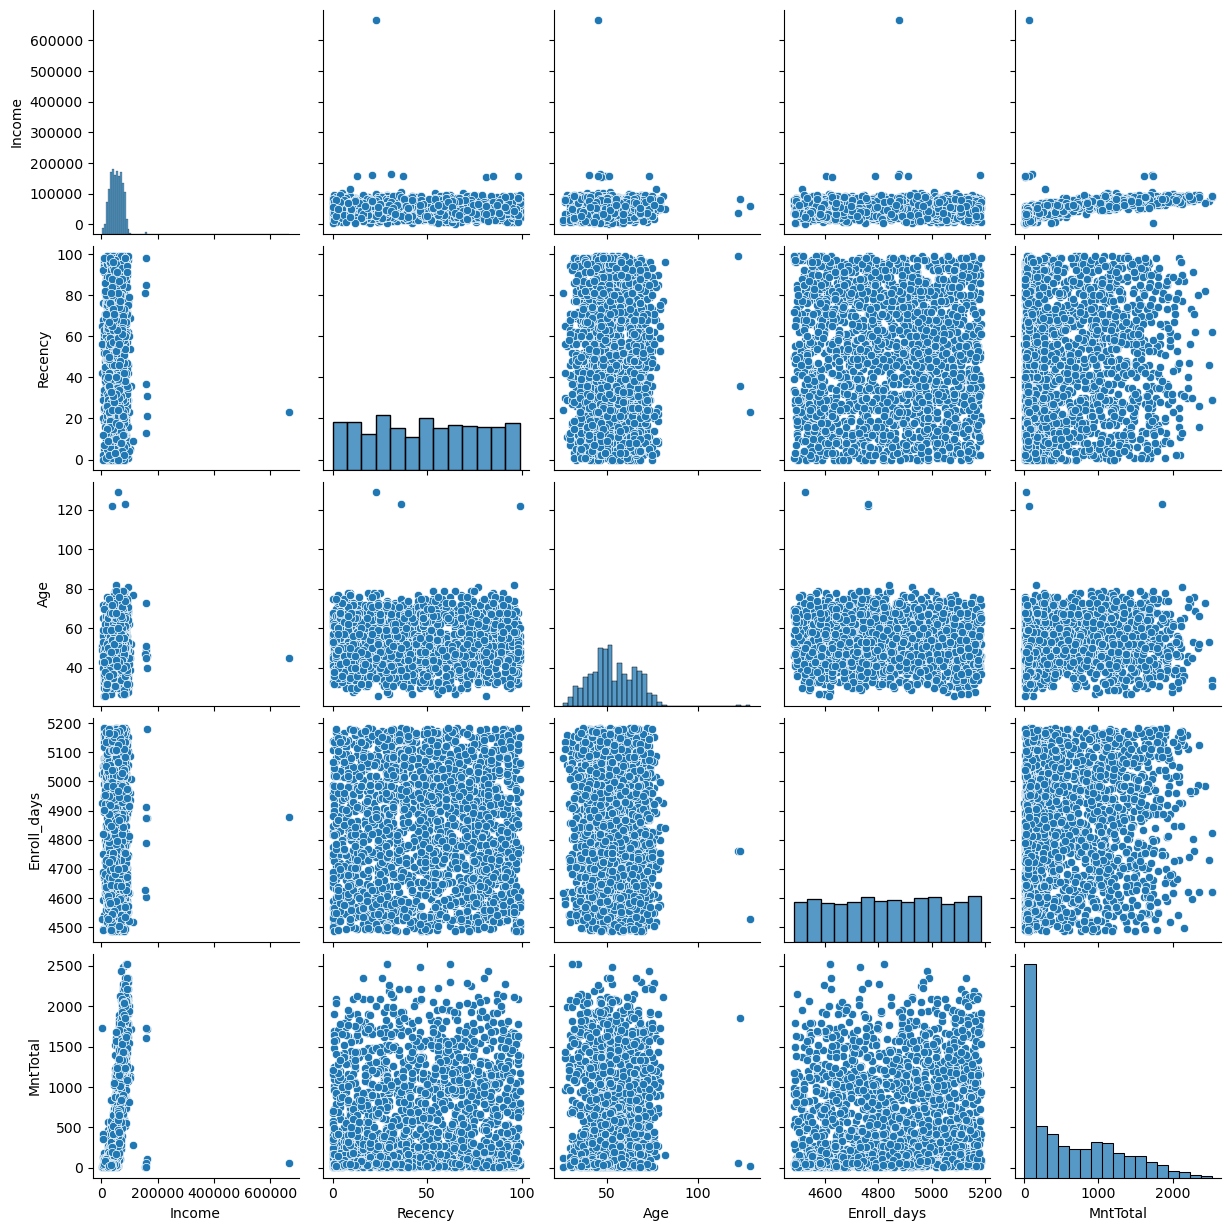

In [38]:
plot_cols = ['Income', 'Recency', 'Age', 'Enroll_days', 'MntTotal']
# vẽ pair plot
sns.pairplot(customer_data[plot_cols])
plt.show()

In [39]:
# xử lý nhiễu (nếu có)
# Nhìn pair plot: có khách hàng Age > 100 (năm sinh 1893, 1899, 1900) và 1 khách hàng có Income = 666666 (quá lớn so với phần còn lại)
# --> xem như nhiễu, loại bỏ
print('Trước khi xử lý:', customer_data.shape)
customer_data = customer_data[(customer_data['Age'] < 100) & (customer_data['Income'] < 200000)]
print('Sau khi xử lý:', customer_data.shape)

Trước khi xử lý: (2240, 33)
Sau khi xử lý: (2236, 33)


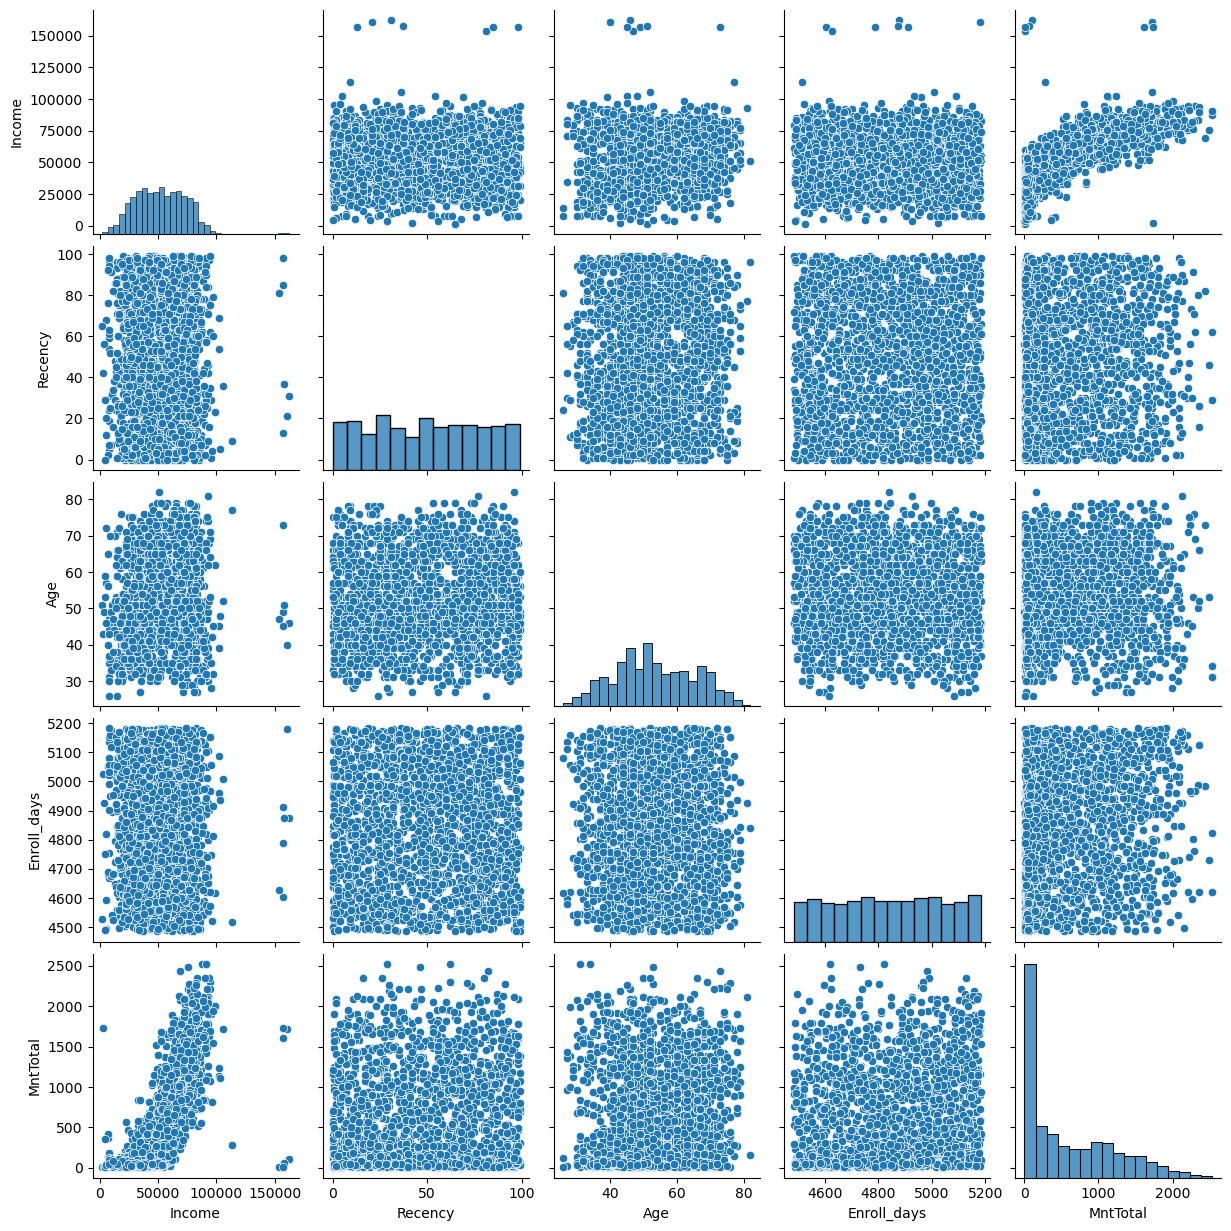

In [40]:
# Vẽ lại pair plot sau khi bỏ nhiễu
sns.pairplot(customer_data[plot_cols])
plt.show()

**Nhận xét:**
- Pair plot cho thấy một vài điểm bất thường: có khách hàng `Age` > 100 (năm sinh 1893, 1899, 1900) và 1 khách hàng có `Income` = 666666 (lớn hơn rất nhiều so với phần còn lại, cao nhất của nhóm còn lại chỉ khoảng 162 nghìn). Đây là nhiễu nên đã loại bỏ 4 dòng (2240 → 2236 dòng).
- Sau khi loại nhiễu, biểu đồ dễ nhìn hơn: `Income` và `MntTotal` có phân bố lệch phải (đa số khách chi tiêu ít, một số ít chi tiêu rất nhiều), `Income` càng cao thì `MntTotal` có xu hướng càng cao. `Recency`, `Age`, `Enroll_days` phân bố khá đều, không thấy quan hệ rõ ràng với các biến còn lại.

In [41]:
import copy
df = customer_data.copy()

# Drop các cột không quan trọng
df.drop([
    'Dt_Customer', 'Year_Birth',
    'Kidhome', 'Teenhome', 'Marital_Status',
    'Z_CostContact', 'Z_Revenue',
    'MntWines', 'MntFruits', 'MntMeatProducts',
    'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
    'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3',
    'AcceptedCmp4','AcceptedCmp5',
    'Complain', 'Response', 'Education', 'Num_Accepted'
], axis=1, inplace=True)

#### A5. Tiền xử lý

**Mã hoá đặc trưng kiểu loại**

In [42]:
# Sau khi gộp đặc trưng ở trên, df chỉ còn các cột số:

print(df.dtypes)
print('Cột kiểu loại còn lại:', list(df.select_dtypes(include='object').columns))

Income                 float64
Recency                  int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
Age                      int64
Enroll_days              int64
Fam_Size                 int64
MntTotal                 int64
dtype: object
Cột kiểu loại còn lại: []


**Chuẩn hoá các thuộc tính kiểu số**

In [43]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df = pd.DataFrame(scaler.fit_transform(df), columns=df.columns, index=df.index)

In [44]:
df.describe() # --> Kiểm tra mean và std có gần với giá trị (0, 1)?

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Age,Enroll_days,Fam_Size,MntTotal
count,2.236000e+03,2.236000e+03,2.236000e+03,2236.000000,2.236000e+03,2.236000e+03,2.236000e+03,2.236000e+03,2.236000e+03,2.236000e+03,2.236000e+03
mean,2.240307e-16,-7.149916e-17,1.271096e-17,0.000000,-7.308803e-17,-1.322734e-16,-1.525315e-16,6.514368e-17,1.150342e-15,2.192641e-16,4.766610e-18
std,1.000224e+00,1.000224e+00,1.000224e+00,1.000224,1.000224e+00,1.000224e+00,1.000224e+00,1.000224e+00,1.000224e+00,1.000224e+00,1.000224e+00
min,-2.346560e+00,-1.696543e+00,-1.203575e+00,-1.470716,-9.110556e-01,-1.783046e+00,-2.192136e+00,-2.316276e+00,-1.750171e+00,-1.758810e+00,-9.987636e-01
25%,-7.688934e-01,-8.675502e-01,-6.861374e-01,-0.751127,-9.110556e-01,-8.600834e-01,-9.557071e-01,-6.924366e-01,-8.559730e-01,-6.565959e-01,-8.924037e-01
50%,-1.298227e-02,-4.016436e-03,-1.686996e-01,-0.031538,-2.268842e-01,-2.447750e-01,2.807217e-01,-9.417994e-02,1.101605e-02,4.456177e-01,-3.481402e-01
75%,7.620935e-01,8.595173e-01,3.487383e-01,0.688050,4.572872e-01,6.781877e-01,6.928646e-01,8.459377e-01,8.668740e-01,4.456177e-01,7.304157e-01
max,5.158923e+00,1.723051e+00,6.557993e+00,8.243731,8.667344e+00,2.216459e+00,6.050723e+00,2.469777e+00,1.707891e+00,2.650045e+00,3.189157e+00


#### A6. Phân cụm KMeans

In [45]:
from sklearn.cluster import KMeans

Phương pháp Elbow: ước lượng số cụm

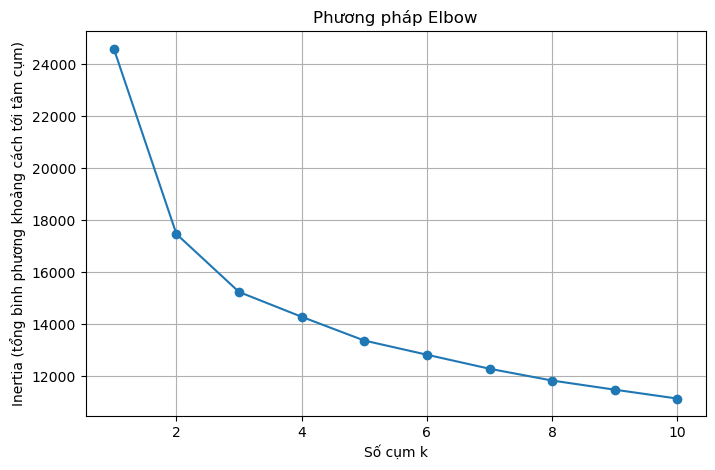

In [46]:
# vẽ biểu đồ elbow để ước lượng số cụm
inertias = []
k_range = range(1, 11)
for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=99)
    km.fit(df)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, marker='o')
plt.xlabel('Số cụm k')
plt.ylabel('Inertia (tổng bình phương khoảng cách tới tâm cụm)')
plt.title('Phương pháp Elbow')
plt.grid(True)
plt.show()

Sử dụng thư viện yellowbrick

In [48]:
pip install yellowbrick

Note: you may need to restart the kernel to use updated packages.


In [49]:
from yellowbrick.cluster import KElbowVisualizer

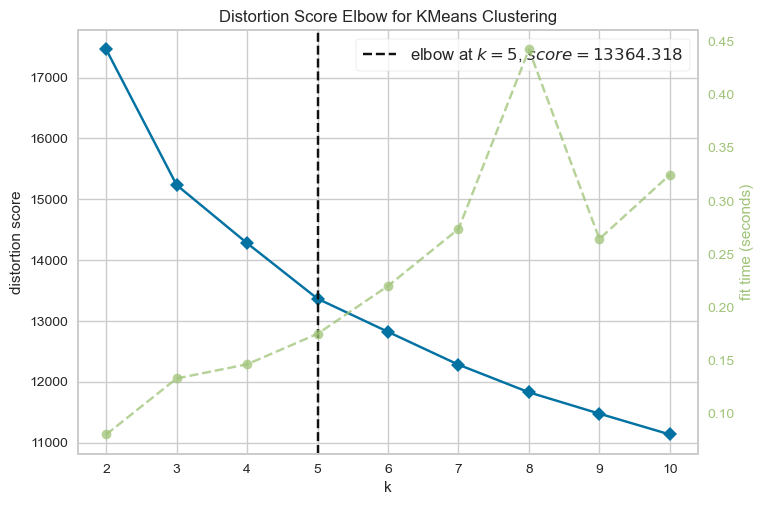

Số cụm theo elbow: 5


In [50]:
model = KMeans(n_init=20, random_state=99)
visualizer = KElbowVisualizer(model, k=10)
visualizer.fit(df)
visualizer.show()
print('Số cụm theo elbow:', visualizer.elbow_value_)

**Phân cụm từ kết quả của phương pháp Elbow**

In [51]:
# Phân cụm với số cụm k theo elbow
K = 5
kmean = KMeans(n_clusters=K, n_init=20, random_state=99)
kmean.fit(df)
print(np.unique(kmean.labels_, return_counts=True))

(array([0, 1, 2, 3, 4], dtype=int32), array([556, 493, 246, 483, 458]))


**Sử dụng PCA giảm số chiều dữ liệu --> trực quan hoá kết quả phân cụm**

In [52]:
from sklearn.decomposition import PCA

In [53]:
# Biến đổi dữ liệu sang không gian 2 chiều pca
pca_2d = PCA(n_components=2)
scores_2d = pca_2d.fit_transform(df)
print('Tỉ lệ phương sai giữ lại:', pca_2d.explained_variance_ratio_.sum())

Tỉ lệ phương sai giữ lại: 0.5248069871347194


**Trực quan hoá kết quả phân cụm**

In [54]:
def visualize_cluster_result(scores, labels):
    '''
    Args:
        scores: biến đổi pca 2d
        labels: nhãn của từng điểm dữ liệu trong scores (chính là label của kết quả phân cụm)
    '''
    # TODO
    fig1, (axes) = plt.subplots(figsize=(8,8))
    scat_1 = sns.scatterplot(
                            x=scores[:,0],
                            y=scores[:,1],
                            hue=labels, ax=axes,
                            palette='Set1', legend='full'
            )
    plt.show()

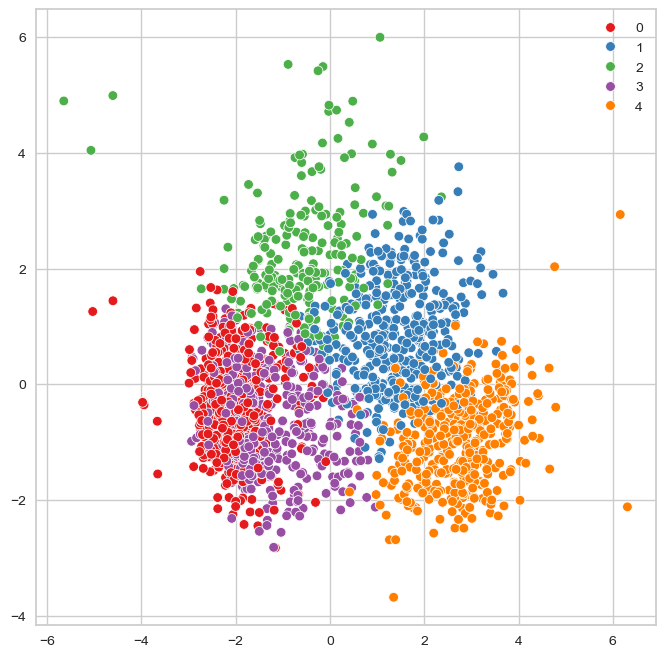

In [55]:
visualize_cluster_result(scores_2d, kmean.labels_)

#### Phân tích kết quả phân cụm (KMeans)

In [56]:
# Gán kết quả phân cụm vào df ban đầu ~ customer_data
kmean_df = customer_data.copy()
kmean_df['Cluster'] = kmean.labels_
kmean_df.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Enroll_days,Fam_Size,Num_Accepted,MntTotal,Cluster
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
5524,1957,Graduation,1,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,65,5148,1,0,1617,1
2174,1954,Graduation,1,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,68,4598,3,0,27,3
4141,1965,Graduation,2,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,57,4797,2,0,776,1
6182,1984,Graduation,2,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,38,4624,3,0,53,0
5324,1981,PhD,2,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,41,4646,3,0,422,2


In [57]:
def visualize_cluster_distribution(labels):
    '''
    Args:
        labels: kết quả phân cụm (danh sách nhãn)
    '''
    ulabels, count = np.unique(labels, return_counts=True)
    plt.figure(figsize=(6,4))

    colors = sns.color_palette('Set2')[0:5]
    
    labels = [f'Cluster {i+1}' for i in range(len(ulabels))]
    plt.pie(count, 
            explode=[0.05]*len(ulabels), 
            labels=labels,
            colors=colors,
            autopct='%1.1f%%',
            textprops=dict(color ="white", fontsize=10),
            counterclock=False,
            startangle=180,
            wedgeprops={"edgecolor":"gray",'linewidth': 1}
        )

    plt.axis('equal')
    plt.legend()
    plt.show()

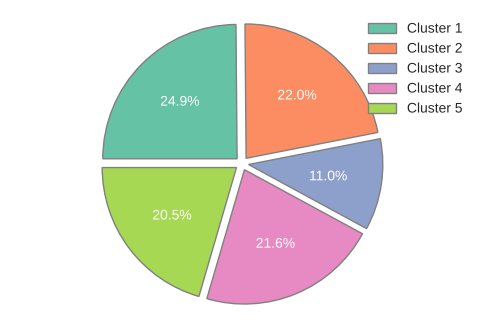

In [ ]:
visualize_cluster_distribution(kmean.labels_)

**Phân tích đa biến + kết quả phân cụm**

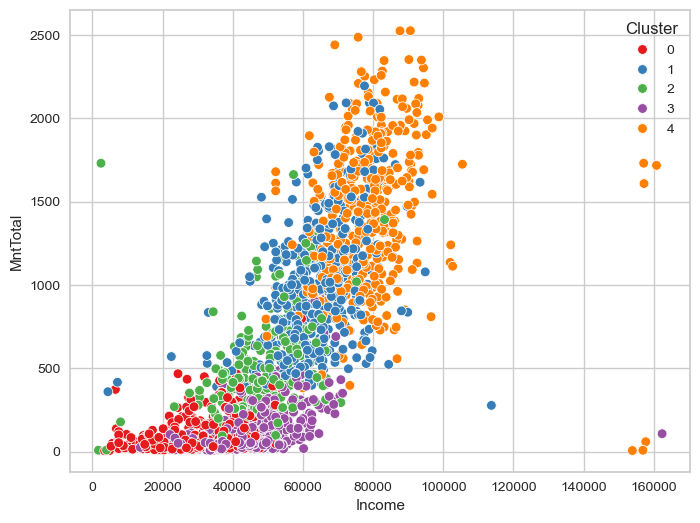

In [58]:
# đặc trưng income và MntTotal: vẽ sns scatterplot với hue là Cluster
plt.figure(figsize=(8, 6))
sns.scatterplot(data=kmean_df, x='Income', y='MntTotal', hue='Cluster', palette='Set1')
plt.show()

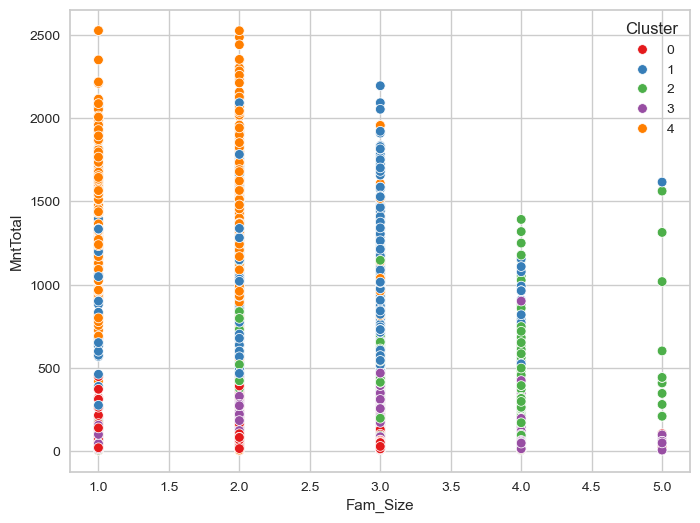

In [59]:
# đặc trưng Fam_Size và MntTotal: vẽ sns scatterplot với hue là Cluster
plt.figure(figsize=(8, 6))
sns.scatterplot(data=kmean_df, x='Fam_Size', y='MntTotal', hue='Cluster', palette='Set1')
plt.show()

**Phân tích danh mục mua hàng**

         MntWines  MntFruits  MntMeatProducts  MntFishProducts  \
Cluster                                                          
0            29.6        6.0             22.4              9.0   
1           556.9       40.3            197.3             53.8   
2           301.3       13.3            104.0             20.9   
3            68.0        5.4             27.8              7.5   
4           615.9       64.8            490.6             95.3   

         MntSweetProducts  MntGoldProds  
Cluster                                  
0                     5.9          17.3  
1                    41.9          69.4  
2                    15.3          52.1  
3                     5.5          15.6  
4                    65.9          74.5  


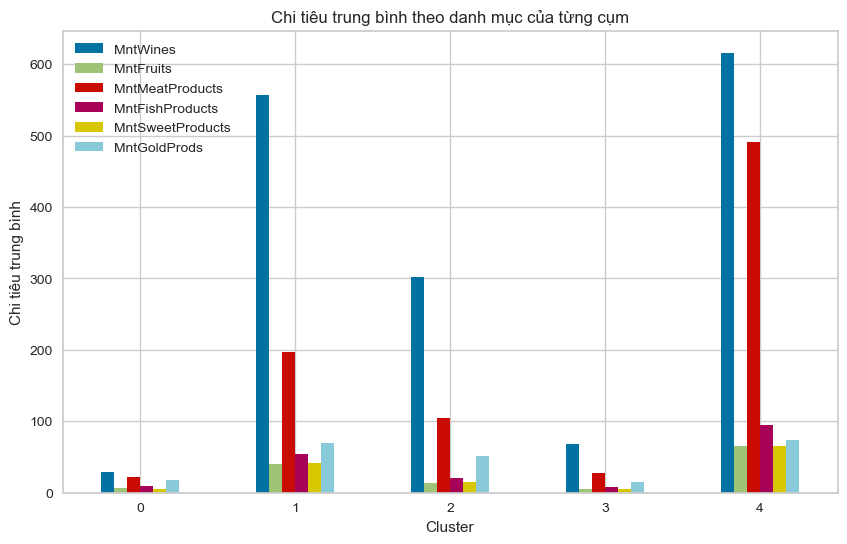

In [60]:
# Phân tích danh mục mua hàng: trung bình chi tiêu từng loại sản phẩm của mỗi cụm
mnt_cols = ['MntWines', 'MntFruits', 'MntMeatProducts',
            'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
cluster_mnt = kmean_df.groupby('Cluster')[mnt_cols].mean()
print(cluster_mnt.round(1))

cluster_mnt.plot(kind='bar', figsize=(10, 6))
plt.ylabel('Chi tiêu trung bình')
plt.title('Chi tiêu trung bình theo danh mục của từng cụm')
plt.xticks(rotation=0)
plt.show()

In [61]:
# Đặc điểm trung bình của từng cụm
profile_cols = ['Income', 'MntTotal', 'Age', 'Fam_Size', 'Recency', 'Enroll_days',
                'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
                'NumStorePurchases', 'NumWebVisitsMonth']
profile = kmean_df.groupby('Cluster')[profile_cols].mean().round(1)
profile['Số khách'] = kmean_df['Cluster'].value_counts().sort_index()
profile

,Income,MntTotal,Age,Fam_Size,Recency,Enroll_days,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Số khách
Cluster,,,,,,,,,,,,
0,29066.4,90.2,45.0,2.5,45.0,4886.6,1.8,2.1,0.5,3.0,7.2,556
1,63417.1,959.6,57.2,2.5,45.4,4904.6,2.6,7.0,3.8,8.7,5.3,493
2,48796.0,507.0,54.6,3.4,48.9,4958.9,6.2,5.7,2.3,5.8,7.2,246
3,43047.0,129.8,57.5,3.2,54.9,4684.9,1.9,2.2,0.8,3.7,5.2,483
4,78527.9,1406.9,53.1,1.7,52.0,4807.7,1.1,4.5,6.3,8.2,2.2,458


**Nhận xét kết quả KMeans (k = 5):**
- **Cụm 0** (556 khách): thu nhập thấp (~29 nghìn), chi tiêu rất ít (~90), tuổi trẻ nhất (~45), vào web nhiều nhưng mua ít.
- **Cụm 1** (493 khách): thu nhập khá (~63 nghìn), chi tiêu cao (~960), mua đều ở cả cửa hàng, web và catalog; chi nhiều nhất cho rượu vang.
- **Cụm 2** (246 khách): thu nhập trung bình (~49 nghìn), gia đình đông nhất (~3.4 người), mua hàng khuyến mãi (`NumDealsPurchases`) nhiều nhất --> nhóm thích săn giảm giá.
- **Cụm 3** (483 khách): thu nhập thấp - trung bình (~43 nghìn), gia đình đông (~3.2 người), tuổi lớn hơn (~57), chi tiêu ít (~130).
- **Cụm 4** (458 khách): thu nhập cao nhất (~78 nghìn), chi tiêu cao nhất (~1400), gia đình nhỏ (~1.7 người), mua nhiều qua catalog, ít vào web; chi nhiều cho thịt và rượu.
- Nhìn chung `Income` và `MntTotal` là hai yếu tố tách cụm rõ nhất; những gia đình đông người (có con) thường chi tiêu ít hơn.
- Biểu đồ PCA 2 chiều chỉ giữ ~52% thông tin nên các cụm nhìn còn chồng lấn lên nhau.

#### A7. Kết hợp PCA và phân cụm
- Biến đổi PCA với số lượng component phù hợp (giữ lại 70-80% thông tin ban đầu).
- Ước lượng số cụm dùng elbow (dùng dữ liệu pca).
- Với số cụm phù hợp, thực hiện phân cụm trên dữ liệu pca.
- Vẽ phân bố kết quả phân cụm.
- Vẽ biểu đồ scatter MntTotal-Income-Cluster.

In [62]:
# vẽ biểu đồ sreeplot
def scree_plot(pca_model, xlabels):
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # explained variance ratio của mô hình pca
    expl_var_ratio = pca_model.explained_variance_ratio_
    # tính cumulative sum của expl_var_ratio (numpy.cumsum)
    expl_var_cumsum = np.cumsum(expl_var_ratio)
    xtick_indx = range(1, len(expl_var_ratio) + 1)
    
    # vẽ các bar thể hiện explained_var
    ax.bar(xtick_indx, expl_var_ratio)
    ax.plot(xtick_indx, expl_var_cumsum, marker='o', color='k')
    
    # set label
    ax.set_xticks(xtick_indx)
    ax.set_xticklabels(xlabels)
    ax.set_xlabel('Principle Components')
    ax.set_ylabel('% variance')
    ax.set_title('Scree Plot')
    
    plt.grid(True)

In [63]:
# PCA giữ lại tất cả các component để xem phương sai giải thích của từng component
pca = PCA()
pca.fit(df)

,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


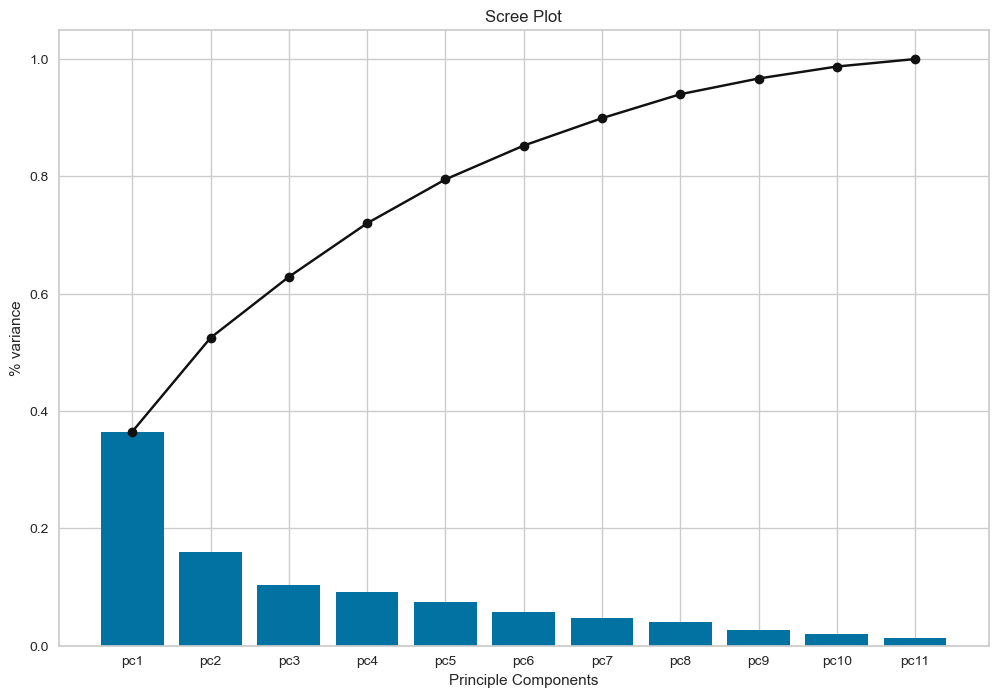

In [64]:
scree_plot(pca, [f'pc{i+1}' for i in range(len(df.columns))])

In [65]:
# biến đổi df sang không gian pca 4 chiều
pca_4d = PCA(n_components=4)
pca_transformed_4d = pca_4d.fit_transform(df)
print('Tỉ lệ phương sai giữ lại với 4 component:', pca_4d.explained_variance_ratio_.sum())

Tỉ lệ phương sai giữ lại với 4 component: 0.7200671436168373


**Nhận xét:** PC1 giải thích khoảng 36% phương sai, PC2 khoảng 16%. Dùng 4 component thì giữ được khoảng 72% thông tin ban đầu (nằm trong khoảng 70-80% theo yêu cầu) nên chọn 4 component. Biểu đồ Elbow trên dữ liệu PCA cho thấy số cụm phù hợp là k = 4.

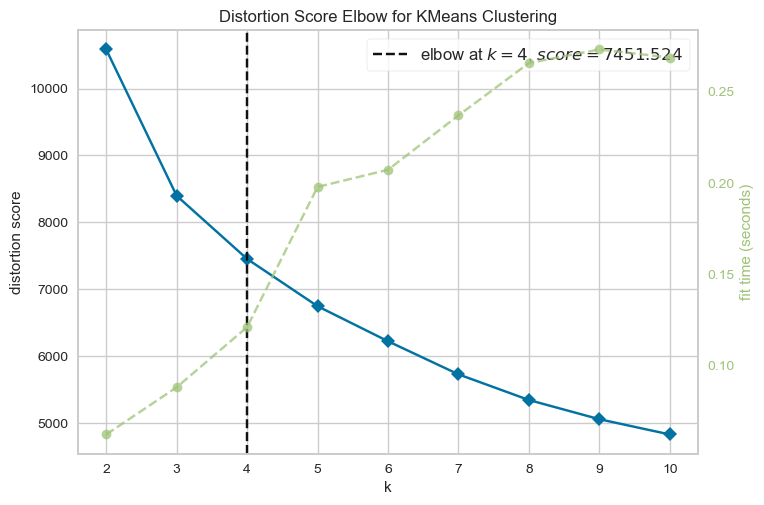

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [66]:
model = KMeans(n_init=20, random_state=99)
visualizer = KElbowVisualizer(model, k=10)
visualizer.fit(pca_transformed_4d)
visualizer.show()

In [67]:
# Phân cụm trên dữ liệu pca với số cụm theo elbow
K_pca = 4
kmean_pca = KMeans(n_clusters=K_pca, n_init=20, random_state=99)
kmean_pca.fit(pca_transformed_4d)
print(np.unique(kmean_pca.labels_, return_counts=True))

(array([0, 1, 2, 3], dtype=int32), array([519, 695, 486, 536]))


In [68]:
# Gán kết quả phân cụm vào df ban đầu ~ customer_data
kmean_pca_df = customer_data.copy()
kmean_pca_df['Cluster'] = kmean_pca.labels_
kmean_pca_df.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Enroll_days,Fam_Size,Num_Accepted,MntTotal,Cluster
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
5524,1957,Graduation,1,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,65,5148,1,0,1617,1
2174,1954,Graduation,1,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,68,4598,3,0,27,0
4141,1965,Graduation,2,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,57,4797,2,0,776,1
6182,1984,Graduation,2,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,38,4624,3,0,53,3
5324,1981,PhD,2,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,41,4646,3,0,422,2


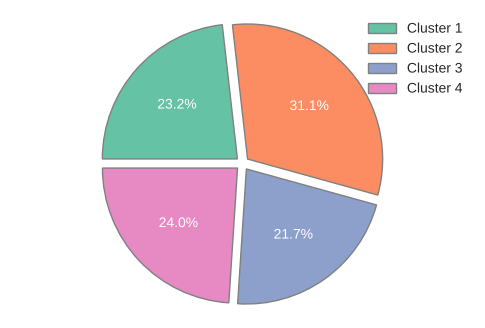

In [ ]:
visualize_cluster_distribution(kmean_pca.labels_)

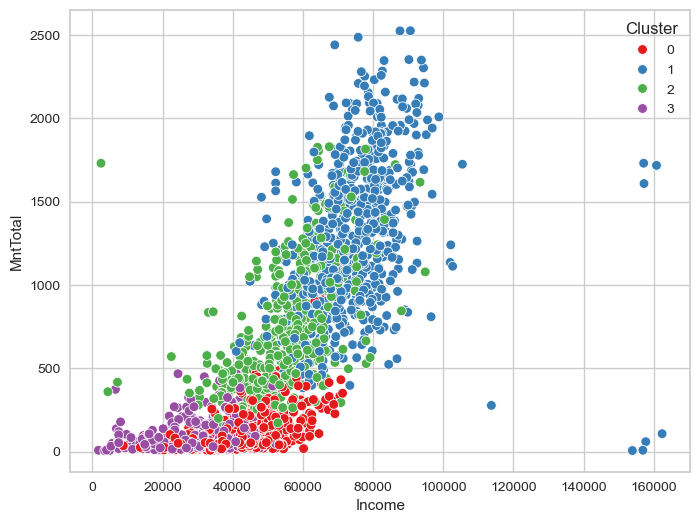

In [69]:
# đặc trưng income và MntTotal: vẽ sns scatterplot với hue là Cluster
plt.figure(figsize=(8, 6))
sns.scatterplot(data=kmean_pca_df, x='Income', y='MntTotal', hue='Cluster', palette='Set1')
plt.show()

In [70]:
profile_pca = kmean_pca_df.groupby('Cluster')[profile_cols].mean().round(1)
profile_pca['Số khách'] = kmean_pca_df['Cluster'].value_counts().sort_index()
profile_pca

,Income,MntTotal,Age,Fam_Size,Recency,Enroll_days,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Số khách
Cluster,,,,,,,,,,,,
0,42154.2,125.9,57.3,3.2,54.2,4687.7,2.0,2.2,0.8,3.7,5.3,519
1,74831.5,1281.2,54.1,1.9,49.4,4823.3,1.4,5.2,5.7,8.5,3.0,695
2,55239.7,722.8,56.8,3.0,47.4,4959.9,4.5,6.7,2.9,7.2,6.5,486
3,28832.8,89.5,44.5,2.6,45.4,4895.2,1.9,2.1,0.5,3.0,7.3,536


**Nhận xét kết quả KMeans trên dữ liệu PCA (k = 4):**
- Cụm 3 (536 khách) giống cụm "thu nhập thấp, chi tiêu rất ít, trẻ" ở trên; cụm 0 (519 khách) giống nhóm "gia đình đông, chi tiêu ít".
- Cụm 1 (695 khách) có thu nhập cao nhất (~75 nghìn), chi tiêu cao nhất (~1280), mua catalog nhiều --> tương ứng việc gộp cụm 1 và cụm 4 của kết quả trước.
- Cụm 2 (486 khách) thu nhập trung bình, chi tiêu khá (~720), mua khuyến mãi và mua web nhiều.
- So với KMeans trên dữ liệu gốc: kết quả có ít cụm hơn (4 so với 5) nhưng các cụm vẫn giải thích được và các nhóm chính (thu nhập cao - chi nhiều, thu nhập thấp - chi ít) vẫn được giữ. Số chiều giảm từ 11 xuống 4 nên tính toán nhanh hơn, đổi lại mất khoảng 28% thông tin.

#### A9. Phân tích kết quả phân cụm (DBSCAN)

In [71]:
from sklearn.cluster import DBSCAN

**Sử dụng knee plot để ước lượng eps**

In [72]:
len(df.columns)

11

In [73]:
from sklearn.neighbors import NearestNeighbors
def knee_plot(n_neighs, data):
    neigh = NearestNeighbors(n_neighbors=n_neighs)
    nbrs = neigh.fit(data)
    distances, indices = nbrs.kneighbors(data)

    # plot
    distances = np.sort(distances, axis=0)
    distances = distances[:,1]
    plt.plot(distances)
    
    return distances

**DBSCAN trên toàn bộ đặc trưng (đã chuẩn hoá)**

Dữ liệu có 11 đặc trưng nên chọn `min_samples` = 2 × số chiều = 22.

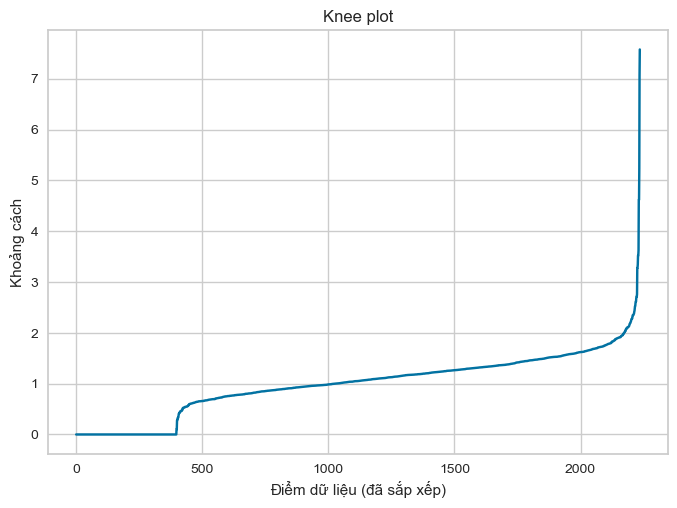

In [74]:
# knee plot: sắp xếp khoảng cách tới láng giềng gần nhất, chỗ đường cong gấp lên là eps
distances = knee_plot(22, df)
plt.xlabel('Điểm dữ liệu (đã sắp xếp)')
plt.ylabel('Khoảng cách')
plt.title('Knee plot')
plt.show()

In [75]:
# Thử vài giá trị eps để xem số cụm và số điểm nhiễu (-1)
for eps in [1.5, 2, 2.5, 3]:
    labels = DBSCAN(eps=eps, min_samples=22).fit(df).labels_
    print('eps =', eps, '| số cụm:', len(set(labels)) - (1 if -1 in labels else 0),
          '| số điểm nhiễu:', (labels == -1).sum())

eps = 1.5 | số cụm: 1 | số điểm nhiễu: 1407
eps = 2 | số cụm: 1 | số điểm nhiễu: 271
eps = 2.5 | số cụm: 1 | số điểm nhiễu: 35
eps = 3 | số cụm: 1 | số điểm nhiễu: 19


(array([-1,  0]), array([ 271, 1965]))


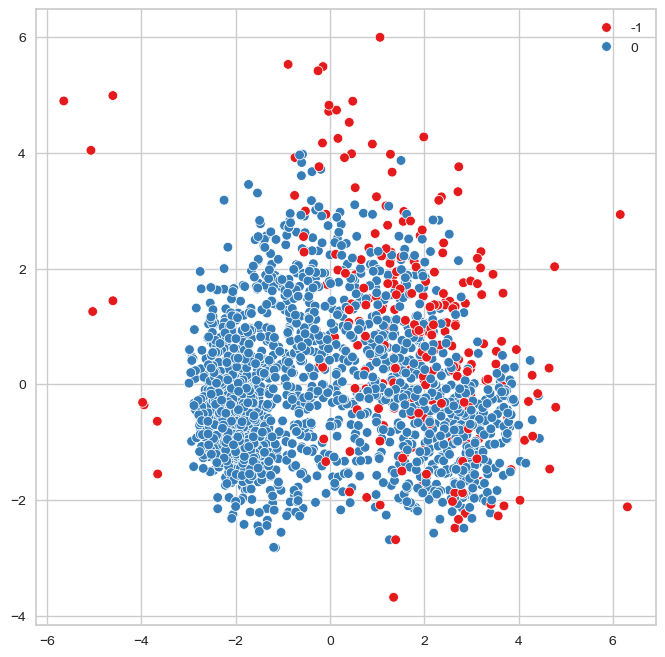

In [76]:
dbscan_full = DBSCAN(eps=2, min_samples=22)
dbscan_full.fit(df)
print(np.unique(dbscan_full.labels_, return_counts=True))
visualize_cluster_result(scores_2d, dbscan_full.labels_)

**Nhận xét:** Với `min_samples` = 22 và eps = 2, DBSCAN chỉ tìm được 1 cụm lớn (1965 điểm) và 271 điểm nhiễu (nhãn -1). Nếu tăng eps thì nhiễu giảm nhưng vẫn chỉ có 1 cụm, nếu giảm eps thì gần như mọi điểm thành nhiễu. Lý do: dữ liệu 11 chiều khá liên tục, không có vùng nào thưa rõ ràng ngăn cách giữa các nhóm khách hàng nên DBSCAN không chia được nhiều cụm như KMeans. Tuy vậy DBSCAN cho biết được những khách hàng "lạ" (nhiễu) khác biệt nhiều so với đa số.

**Sử dụng PCA thu giảm số chiều --> phân cụm**

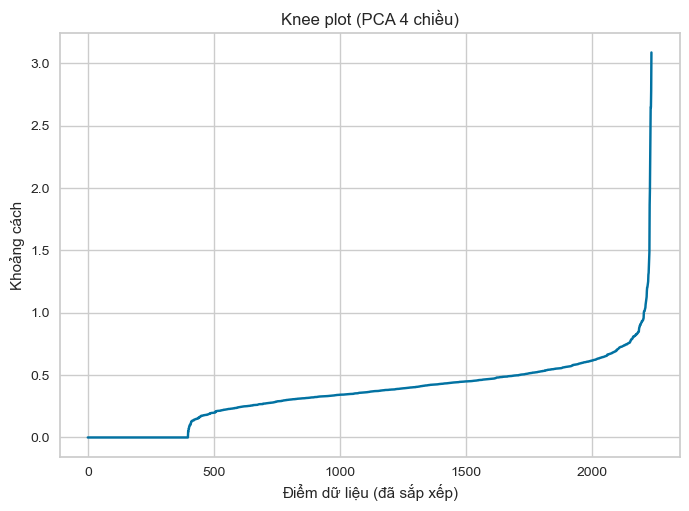

eps = 0.5 | số cụm: 9 | số điểm nhiễu: 1807
eps = 0.8 | số cụm: 4 | số điểm nhiễu: 301
eps = 1 | số cụm: 1 | số điểm nhiễu: 73
eps = 1.2 | số cụm: 1 | số điểm nhiễu: 32


In [77]:
# DBSCAN trên dữ liệu pca 4 chiều, min_samples = 2 x 4 = 8
distances = knee_plot(8, pca_transformed_4d)
plt.xlabel('Điểm dữ liệu (đã sắp xếp)')
plt.ylabel('Khoảng cách')
plt.title('Knee plot (PCA 4 chiều)')
plt.show()

for eps in [0.5, 0.8, 1, 1.2]:
    labels = DBSCAN(eps=eps, min_samples=8).fit(pca_transformed_4d).labels_
    print('eps =', eps, '| số cụm:', len(set(labels)) - (1 if -1 in labels else 0),
          '| số điểm nhiễu:', (labels == -1).sum())

(array([-1,  0,  1,  2,  3]), array([ 301, 1912,    8,    8,    7]))


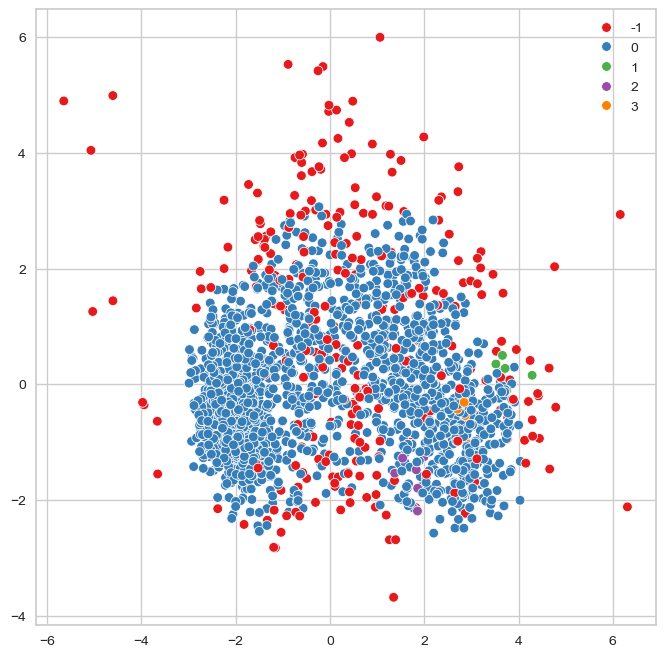

In [78]:
dbscan_pca = DBSCAN(eps=0.8, min_samples=8)
dbscan_pca.fit(pca_transformed_4d)
print(np.unique(dbscan_pca.labels_, return_counts=True))
visualize_cluster_result(scores_2d, dbscan_pca.labels_)

**Nhận xét:** Trên dữ liệu PCA 4 chiều (eps = 0.8, `min_samples` = 8) DBSCAN tìm được 1 cụm rất lớn (1912 điểm), 3 cụm rất nhỏ (7-8 điểm) và 301 điểm nhiễu. Các cụm nhỏ này không có nhiều ý nghĩa trong việc phân nhóm khách hàng. Giảm chiều giúp DBSCAN tính nhanh hơn nhưng kết quả vẫn không chia nhóm tốt bằng KMeans.

**Chia nhỏ đặc trưng**

In [80]:
sub_df = df[['Income', 'MntTotal', 'Enroll_days']]

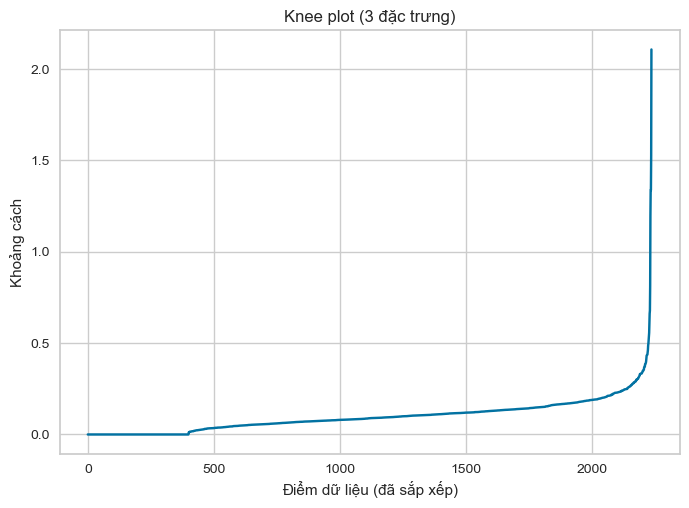

eps = 0.2 | số cụm: 33 | số điểm nhiễu: 752
eps = 0.25 | số cụm: 8 | số điểm nhiễu: 314
eps = 0.3 | số cụm: 1 | số điểm nhiễu: 165
eps = 0.4 | số cụm: 1 | số điểm nhiễu: 50


In [81]:
# DBSCAN trên 3 đặc trưng Income, MntTotal, Enroll_days, min_samples = 2 x 3 = 6
distances = knee_plot(6, sub_df)
plt.xlabel('Điểm dữ liệu (đã sắp xếp)')
plt.ylabel('Khoảng cách')
plt.title('Knee plot (3 đặc trưng)')
plt.show()

for eps in [0.2, 0.25, 0.3, 0.4]:
    labels = DBSCAN(eps=eps, min_samples=6).fit(sub_df).labels_
    print('eps =', eps, '| số cụm:', len(set(labels)) - (1 if -1 in labels else 0),
          '| số điểm nhiễu:', (labels == -1).sum())

(array([-1,  0,  1,  2,  3,  4,  5,  6,  7]), array([ 314, 1859,   20,    9,   15,    6,    4,    5,    4]))


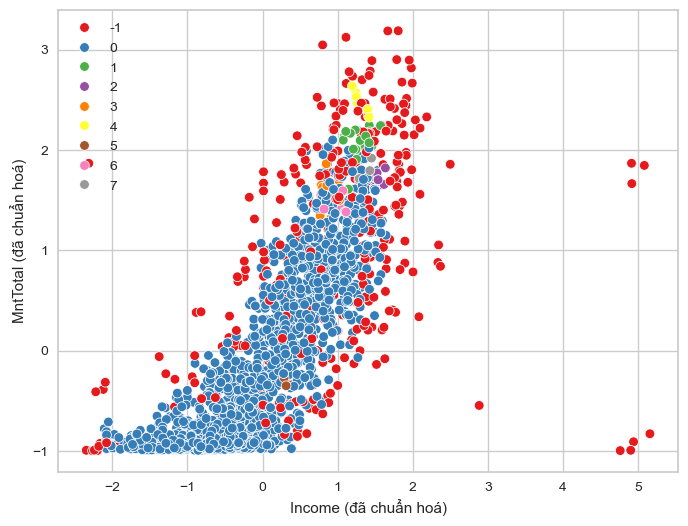

In [82]:
dbscan_sub = DBSCAN(eps=0.25, min_samples=6)
dbscan_sub.fit(sub_df)
print(np.unique(dbscan_sub.labels_, return_counts=True))

plt.figure(figsize=(8, 6))
sns.scatterplot(x=sub_df['Income'], y=sub_df['MntTotal'], hue=dbscan_sub.labels_,
                palette='Set1', legend='full')
plt.xlabel('Income (đã chuẩn hoá)')
plt.ylabel('MntTotal (đã chuẩn hoá)')
plt.show()

**Nhận xét:** Khi chỉ dùng 3 đặc trưng (`Income`, `MntTotal`, `Enroll_days`) với eps = 0.25, `min_samples` = 6: có 1 cụm chính (1859 điểm), 7 cụm nhỏ (4-20 điểm) và 314 điểm nhiễu. Các điểm nhiễu trung bình có thu nhập và chi tiêu cao hơn hẳn phần còn lại (chuẩn hoá: Income ~0.9, MntTotal ~1.0 so với ~-0.15). DBSCAN rất nhạy với eps: chỉ cần tăng từ 0.25 lên 0.3 thì các cụm nhỏ biến mất và chỉ còn 1 cụm. **Kết luận chung:** với bộ dữ liệu khách hàng này, KMeans (kết hợp elbow) phù hợp hơn để phân khúc khách hàng, còn DBSCAN hữu ích hơn để phát hiện điểm bất thường.

### B. Dữ liệu taxi 

In [83]:
import pandas as pd

In [84]:
df = pd.read_csv('data/taxi_data.csv')
df.head()

,LON,LAT,NAME
0,28.17858,-25.73882,11th Street Taxi Rank
1,28.17660,-25.73795,81 Bazaar Street Taxi Rank
2,27.83239,-26.53722,Adams Road Taxi Rank
3,28.12514,-26.26666,Alberton City Mall Taxi Rank
4,28.10144,-26.10567,Alexandra Main Taxi Rank


**Biểu diễn giá trị toạ độ trên bản đồ**

In [85]:
import folium, re

In [89]:
df = df.dropna(subset=['LAT', 'LON'])
X = df[['LAT','LON']].values
m = folium.Map(location=[X[:,0].mean(), X[:,1].mean()], tiles='OpenStreetMap', zoom_start=10)

In [90]:
for _,row in df.iterrows():
    folium.CircleMarker(
        location=[row.LAT,row.LON],
        radius=5,
        popup=re.sub(r'\W+',' ',row.NAME),
        fill=True
    ).add_to(m)

# Loại bỏ non-word chars
title = '''<h3 align="center" style="font-size:30px"><b>Given Data</b></h3>'''
m.get_root().html.add_child(folium.Element(title))
m

In [92]:
pip install kneed

Note: you may need to restart the kernel to use updated packages.


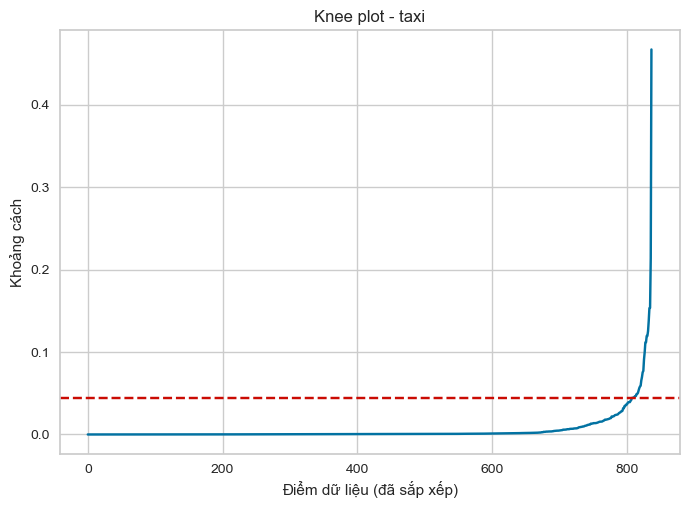

eps ước lượng: 0.04478924201189146


In [93]:
# Knee plot để ước lượng eps
# min_samples = 5, dữ liệu 2 chiều (LAT, LON)
from kneed import KneeLocator

distances = knee_plot(5, X)
plt.xlabel('Điểm dữ liệu (đã sắp xếp)')
plt.ylabel('Khoảng cách')
plt.title('Knee plot - taxi')

# tìm điểm gấp (knee) của đường cong
kl = KneeLocator(range(len(distances)), distances, curve='convex', direction='increasing')
eps = distances[kl.knee] if kl.knee is not None else 0.01
plt.axhline(eps, color='r', linestyle='--')
plt.show()
print('eps ước lượng:', eps)

In [94]:
#First create an array of color schemes
colors = ['royalblue', 'maroon', 'forestgreen', 'mediumorchid', 'tan', 'deeppink', 
          'olive', 'goldenrod', 'lightcyan', 'navy','springgreen','midnightblue',
         'red','brown','limegreen','lime','pink','orchid','crimson','m']*10

In [95]:
# Sử dụng DBSCAN để phân cụm
dbscan_taxi = DBSCAN(eps=eps, min_samples=5)
dbscan_taxi.fit(X)

df['DBSCAN_labels'] = dbscan_taxi.labels_
# nhãn -1 là điểm nhiễu -> tô màu đen
df['dbscan_colors'] = df['DBSCAN_labels'].apply(lambda x: colors[x] if x >= 0 else 'black')

n_clusters = len(set(dbscan_taxi.labels_)) - (1 if -1 in dbscan_taxi.labels_ else 0)
print('Số cụm:', n_clusters, '| số điểm nhiễu:', (dbscan_taxi.labels_ == -1).sum())

Số cụm: 27 | số điểm nhiễu: 69


In [96]:
def create_map(cluster_column, colors_column, title):
    m = folium.Map(location=[X[:,0].mean(),X[:,1].mean()],tiles='OpenStreetMap',zoom_start=8.5)
    for _,row in df.iterrows():
        folium.CircleMarker(
            location=[row.LAT,row.LON],
            radius=5,
            popup=str(row[cluster_column]),
            fill=True,
            color=row[colors_column],
            fill_color=row[colors_column],
        ).add_to(m)

    print(title)
    return m

In [97]:
create_map('DBSCAN_labels', 'dbscan_colors', 'DBSCAN clustering')

DBSCAN clustering


**Nhận xét:** Mỗi màu là một cụm các điểm taxi nằm gần nhau, các điểm màu đen là nhiễu (không thuộc cụm nào). DBSCAN không cần chọn trước số cụm, chỉ cần eps (ước lượng từ knee plot) và `min_samples`, hơn nữa với dữ liệu toạ độ địa lý thì các cụm có hình dạng bất kỳ và DBSCAN xử lý tốt hơn KMeans. Số cụm và số điểm nhiễu xem ở kết quả in phía trên.